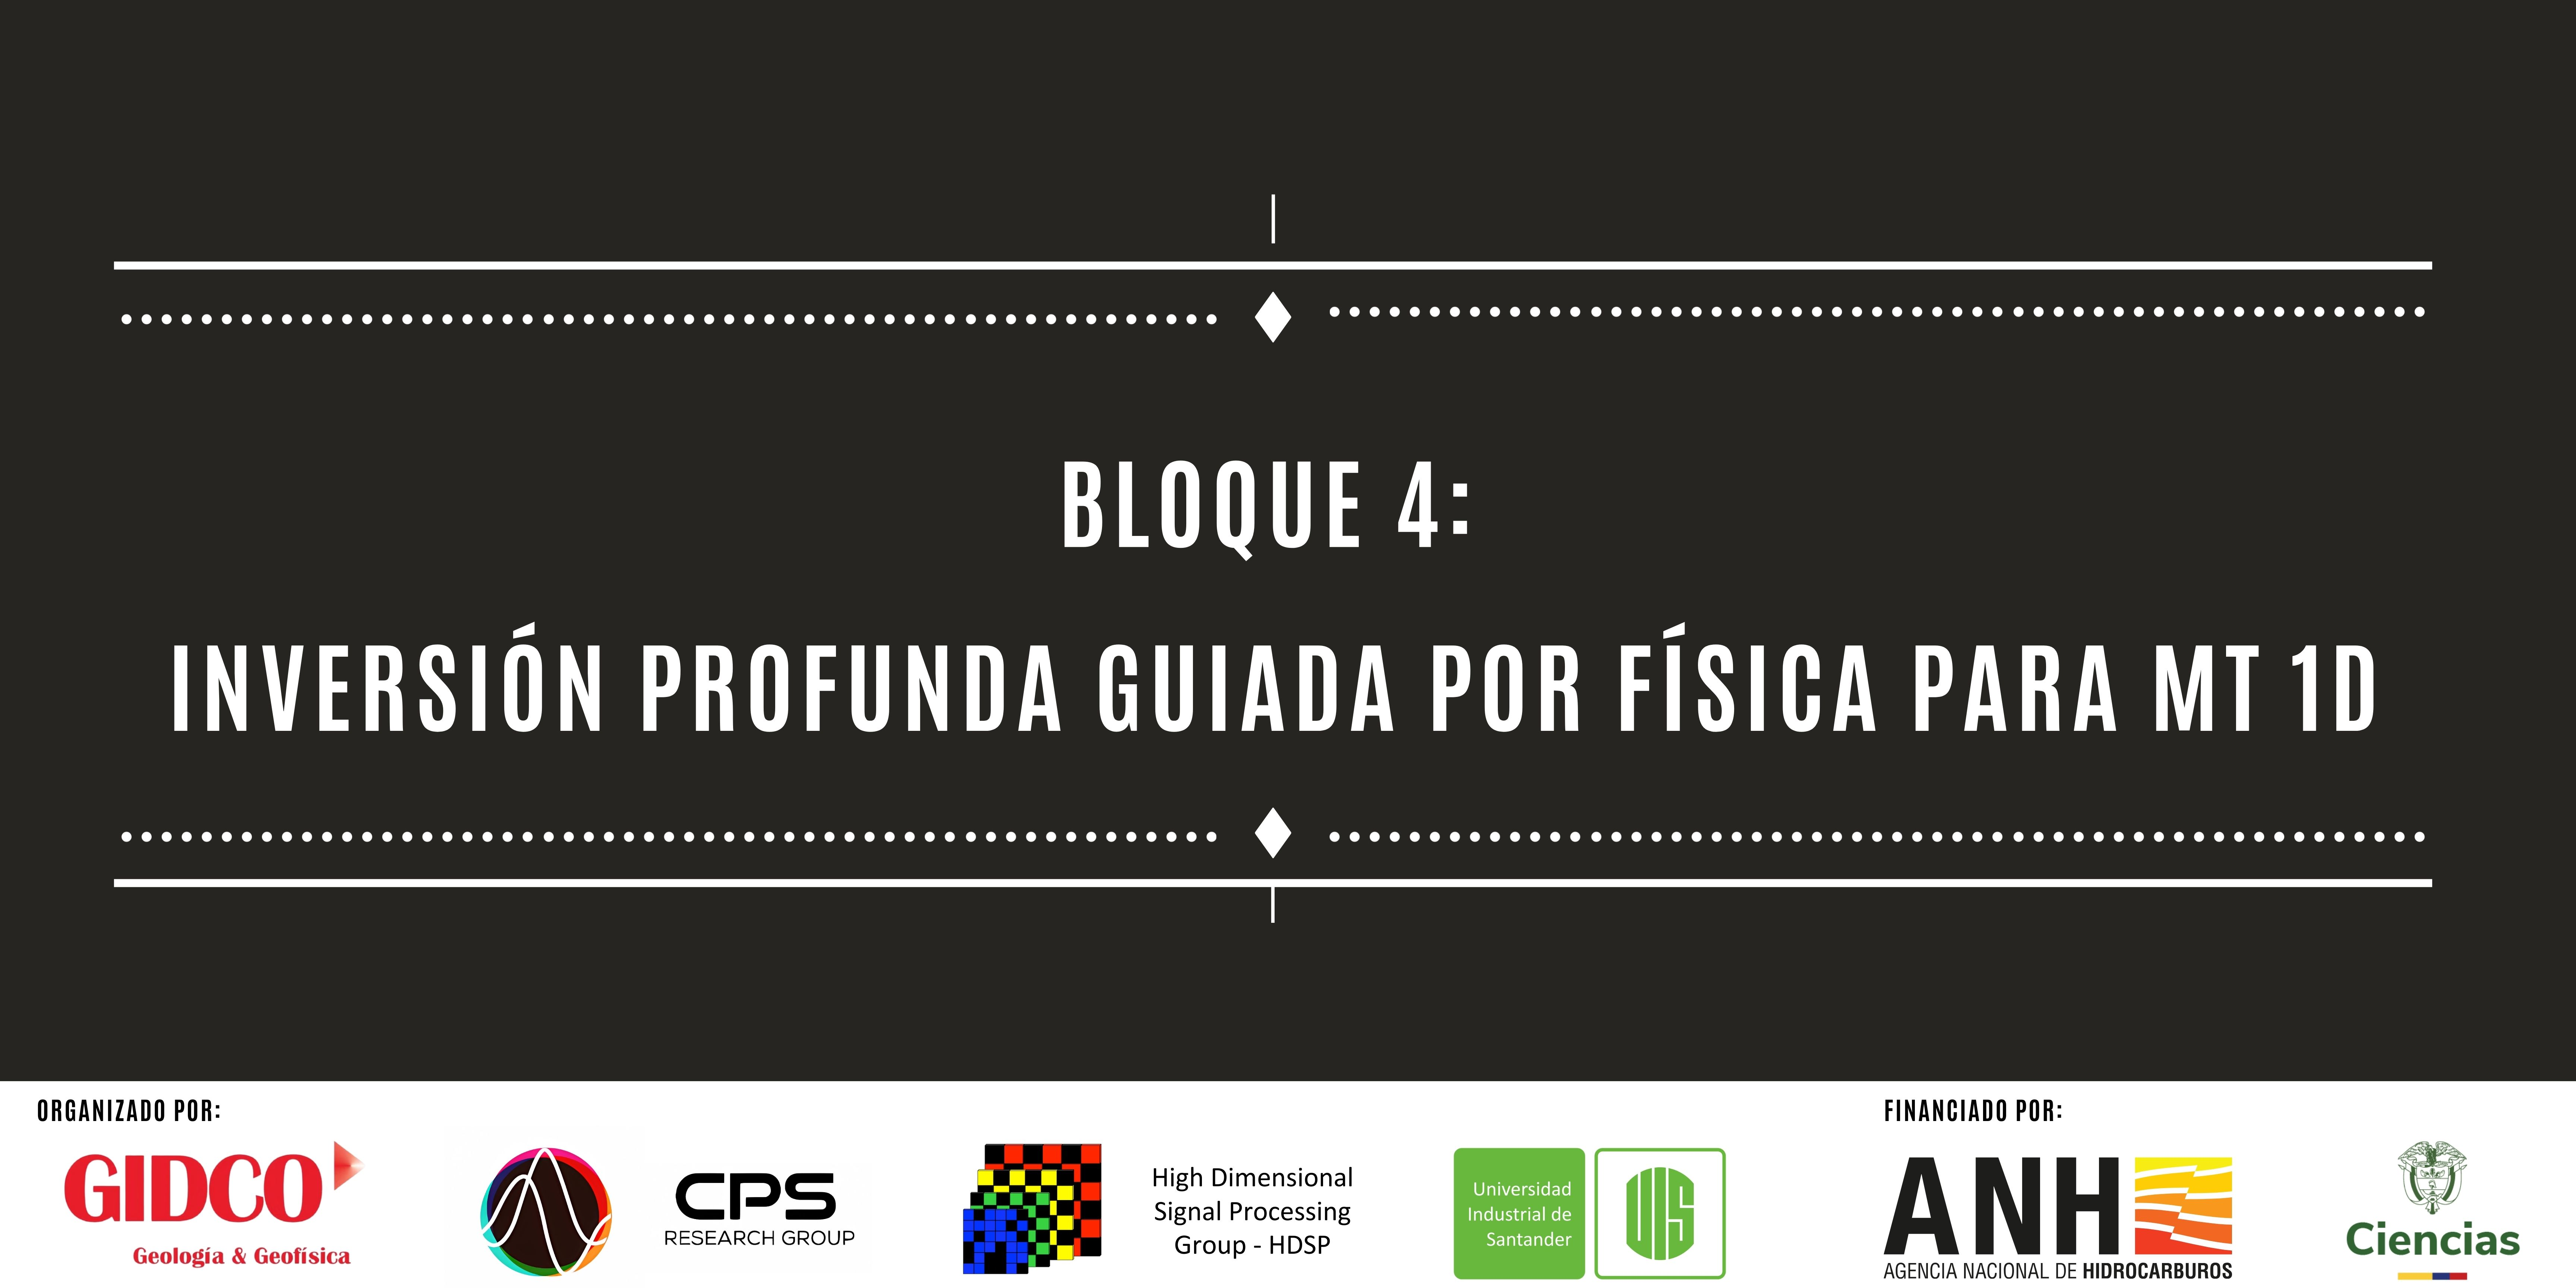

# Inversión $1$D Magnetotelúrica (MT) guiada por física — Caso real

Este notebook implementa un esquema de inversión magnetotelúrica (MT) $1$D guiada por física en un caso real.  
El objetivo es ajustar una red neuronal para predecir un modelo de resistividad por capas cuya respuesta, calculada mediante el operador directo MT, reproduzca el dato observado.

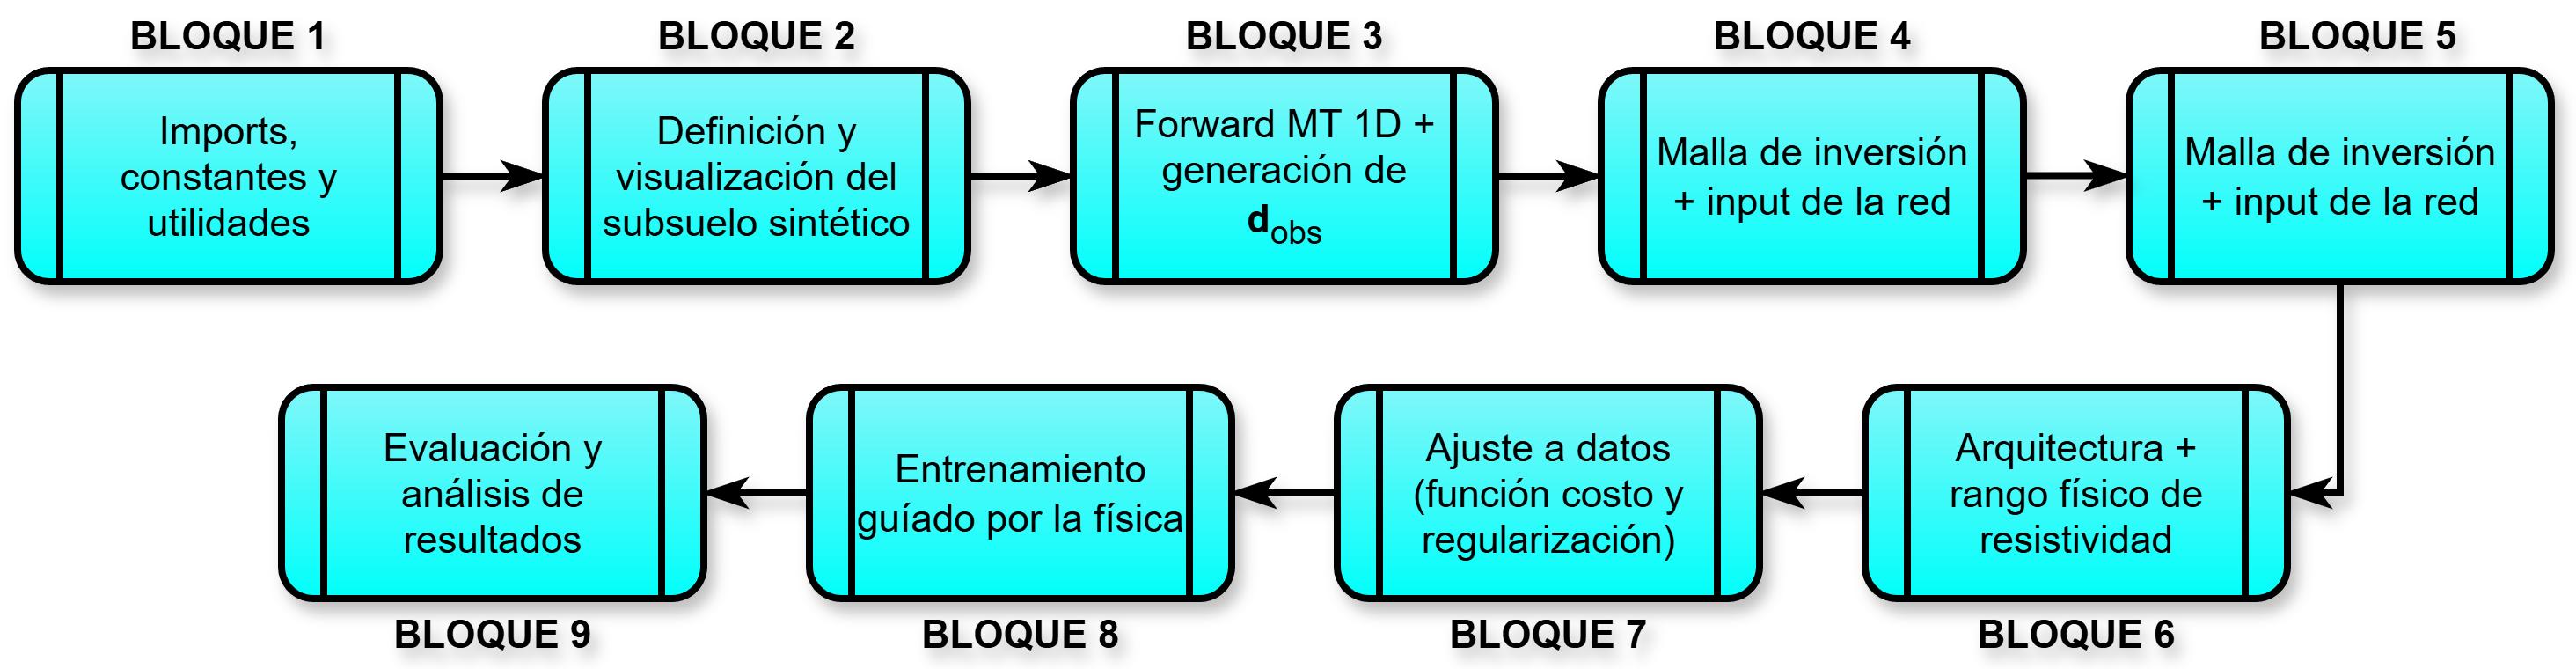

## Bloque 1. Configuración inicial y utilidades

En este bloque se prepara el entorno de trabajo del notebook.  
Se importan las librerías necesarias, se define la constante física relevante del problema y se implementan funciones auxiliares para:

- representar modelos $1$D por capas,
- crear el optimizador,
- construir variables de entrada,
- y mapear la salida de la red neuronal al rango físico de resistividades.

In [ ]:
#@title 1.1) Imports
!pip install tensorflow
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
import math
from scipy import constants

mu = constants.mu_0  # H/m
print("Listo")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 733.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 127.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 83.9 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


Listo


In [ ]:
#@title 1.2) Utilidades (modelos 1D, optimizador, features)
def drawModel1D(ax, thickness, values, plot="semilogx",
                xlabel=r"Resistivity $(\Omega\,m)$", zlabel="Depth (m)", z0=0, **kwargs):
    thickness = np.asarray(thickness, float)
    values = np.asarray(values, float)
    nLayers = len(values)

    px = np.zeros(nLayers * 2)
    pz = np.zeros(nLayers * 2)
    z1 = np.cumsum(thickness) + z0

    for i in range(nLayers):
        px[2*i] = values[i]
        px[2*i+1] = values[i]
        if i == nLayers - 1:
            pz[2*i+1] = z1[i-1] * 1.2
        else:
            pz[2*i+1] = z1[i]
            pz[2*i+2] = z1[i]

    getattr(ax, plot)(px, pz+z0, **kwargs)
    ax.set_ylabel(zlabel)
    ax.set_xlabel(xlabel)
    ax.set_ylim(pz[-1], pz[0])
    ax.grid(True)

def make_optimizer(name, lr, wd=0.0, clipnorm=None):
    name = str(name)
    if name == "Adam":
        return tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=clipnorm)
    if name == "RMSprop":
        return tf.keras.optimizers.RMSprop(learning_rate=lr, clipnorm=clipnorm)
    if name == "SGD":
        return tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9, clipnorm=clipnorm)
    try:
        return tf.keras.optimizers.AdamW(learning_rate=lr, weight_decay=wd, clipnorm=clipnorm)
    except Exception:
        try:
            return tf.keras.optimizers.experimental.AdamW(learning_rate=lr, weight_decay=wd, clipnorm=clipnorm)
        except Exception:
            print("⚠️ AdamW no disponible; usando Adam.")
            return tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=clipnorm)

def make_features(z_complex, use_phase):
    z = np.asarray(z_complex)
    logabs = np.log10(np.abs(z) + 1e-30)
    if not use_phase:
        return logabs.astype(np.float32)
    phase = np.unwrap(np.angle(z))
    return np.concatenate([logabs, phase]).astype(np.float32)

def sigmoid_to_rho(sig, rho_min, rho_max):
    a = np.log10(rho_min); b = np.log10(rho_max)
    log10rho = a + sig * (b - a)
    return 10.0 ** log10rho

print("Utilidades listas")

Utilidades listas


## Bloque 2. Lectura y reconstrucción del dato observado real

En este bloque se carga un archivo $.edi$ con MTpy-v2 y se extraen los periodos, la resistividad aparente $\rho_a^{xy}(T)$ y la fase $\phi^{xy}(T)$ del modo $xy$.  
A partir de estas cantidades, se reconstruye la impedancia compleja observada $Z_{xy}(\omega)$, que será el dato de entrada del proceso de inversión.

Para evitar ambigüedades de unidades en el tensor de impedancia, se usa la relación:

$$
|Z_{xy}(\omega)| = \sqrt{\rho_a^{xy}(\omega)\,\mu_0\,\omega}
$$

$$
Z_{xy}(\omega) = |Z_{xy}(\omega)|\,e^{i\phi^{xy}(\omega)}
$$

con $\omega = 2\pi f$ y $f = 1/T$.

In [ ]:
#@title 2.1) Instalar MTpy-v2
!pip -q install mtpy-v2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 513.9/513.9 kB 18.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.6/485.6 kB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.1/156.1 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 102.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 791.7/791.7 kB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 188.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 342.5/342.5 kB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.6/37.6 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 93.9 MB/s eta 0:00:00
   ━━━━━━━━━━

In [ ]:
#@title 2.2) Cargar EDI  #@param {display-mode:"form"}
from mtpy import MT

EDI_FILE = "YNP05.edi"  #@param {type:"string"}
mt = MT(EDI_FILE)
mt.read()

print("Archivo:", EDI_FILE)
print("Station:", getattr(mt, "station", None))
print("Has Z:", hasattr(mt, "Z"))
print("Z attrs (preview):", [a for a in dir(mt.Z) if "res" in a.lower() or "phase" in a.lower() or a.lower() in ["z","period","periods"]][:30])

Archivo: YNP05.edi
Station: YNP05S
Has Z: True
Z attrs (preview): ['period', 'phase', 'phase_det', 'phase_error', 'phase_error_det', 'phase_error_xx', 'phase_error_xy', 'phase_error_yx', 'phase_error_yy', 'phase_model_error', 'phase_model_error_det', 'phase_model_error_xx', 'phase_model_error_xy', 'phase_model_error_yx', 'phase_model_error_yy', 'phase_tensor', 'phase_xx', 'phase_xy', 'phase_yx', 'phase_yy', 'res_det', 'res_error_det', 'res_error_xx', 'res_error_xy', 'res_error_yx', 'res_error_yy', 'res_model_error_det', 'res_model_error_xx', 'res_model_error_xy', 'res_model_error_yx']


In [ ]:
#@title 2.3) Extraer $T$, $\rho_a^{xy}$ y $\phi^{xy}$ (filtrado)
mu0 = constants.mu_0

periods = None
for candidate in ["period", "periods"]:
    if hasattr(mt, candidate):
        periods = np.array(getattr(mt, candidate))
        break
if periods is None:
    for candidate in ["period", "periods"]:
        if hasattr(mt.Z, candidate):
            periods = np.array(getattr(mt.Z, candidate))
            break
if periods is None:
    raise RuntimeError("No encontré periodos en mt o mt.Z.")

if hasattr(mt.Z, "res_xy") and hasattr(mt.Z, "phase_xy"):
    rhoa_xy = np.array(mt.Z.res_xy)
    phase_xy = np.array(mt.Z.phase_xy)
else:
    raise RuntimeError("No encontré mt.Z.res_xy / mt.Z.phase_xy.")

frequencies_np = 1.0 / periods
omega = 2*np.pi*frequencies_np

mask = np.isfinite(periods) & np.isfinite(rhoa_xy) & np.isfinite(phase_xy) & (periods > 0) & (rhoa_xy > 0)
periods = periods[mask]
frequencies_np = frequencies_np[mask]
omega = omega[mask]
rhoa_xy = rhoa_xy[mask]
phase_xy = phase_xy[mask]

print("N =", len(periods), "| T:", periods.min(), "→", periods.max(), "s")

N = 37 | T: 0.00390625 → 1024.002621446711 s


In [ ]:
#@title 2.4) Reconstruir $Z_{xy}$ en $\Omega$ (observación)
absZ_xy = np.sqrt(rhoa_xy * mu0 * omega)
phi_rad = np.deg2rad(phase_xy)
Zxy = absZ_xy * (np.cos(phi_rad) + 1j*np.sin(phi_rad))

z_obs = tf.cast(Zxy, tf.complex128)
print("|Zxy|:", float(np.abs(Zxy).min()), "→", float(np.abs(Zxy).max()), "Ω")

|Zxy|: 0.0006422033251575934 → 0.8517325305413692 Ω


In [ ]:
#@title 2.5) Chequeo: $\rho_a$ y fase desde $Z_{xy}$
rhoa_chk = (np.abs(Zxy)**2) / (mu0 * omega)
phase_chk = np.rad2deg(np.angle(Zxy))

print("max rel error rhoa:", np.max(np.abs(rhoa_chk - rhoa_xy) / (rhoa_xy + 1e-30)))
print("max abs error phase (deg):", np.max(np.abs(phase_chk - phase_xy)))

max rel error rhoa: 6.402431486955772e-16
max abs error phase (deg): 7.105427357601002e-15


## Bloque 3. Visualización del dato observado y profundidad de penetración

En esta etapa se inspeccionan las curvas observadas del modo $xy$ y se verifica la consistencia entre las cantidades leídas del archivo y las reconstruidas a partir de $Z_{xy}(\omega)$.  
Además, se explora la profundidad de penetración estimada con MTpy como referencia cualitativa del rango de sensibilidad del dato.

### Curvas observadas $\rho_a^{xy}(T)$ y $\phi^{xy}(T)$

Se grafican:

- $\rho_a^{xy}$ en escala log-log,
- $\phi^{xy}$ en semilog-x, usando $\operatorname{unwrap}$ para continuidad visual.

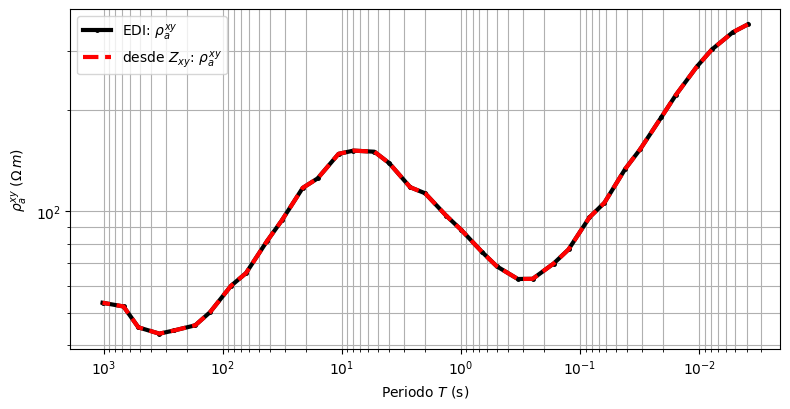

In [ ]:
#@title 3.1) Plot $\rho_a^{xy}$ (EDI vs desde $Z_{xy}$)
plt.figure(figsize=(8.0, 4.2))
plt.loglog(periods, rhoa_xy, "k.-", lw=3.0, ms=5, label=r"EDI: $\rho_a^{xy}$")
plt.loglog(periods, rhoa_chk, "r--", lw=3.0, label=r"desde $Z_{xy}$: $\rho_a^{xy}$")
plt.gca().invert_xaxis()
plt.xlabel(r"Periodo $T$ (s)")
plt.ylabel(r"$\rho_a^{xy}$ ($\Omega\,m$)")
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()

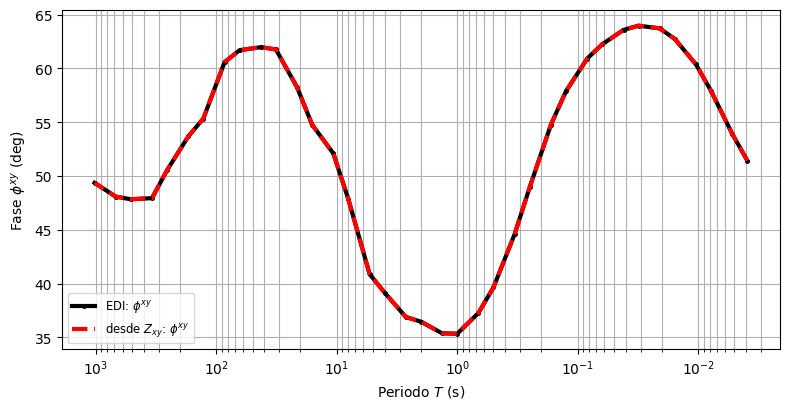

In [ ]:
#@title 3.2) Plot $\phi^{xy}$ (EDI vs desde $Z_{xy}$)
phase_calc = np.rad2deg(np.unwrap(np.angle(Zxy)))
phase_edi  = np.rad2deg(np.unwrap(np.deg2rad(phase_xy)))

plt.figure(figsize=(8.0, 4.2))
plt.semilogx(periods, phase_edi, "k.-", lw=3.0, ms=5, label=r"EDI: $\phi^{xy}$")
plt.semilogx(periods, phase_calc, "r--", lw=3.0, label=r"desde $Z_{xy}$: $\phi^{xy}$")
plt.gca().invert_xaxis()
plt.xlabel(r"Periodo $T$ (s)")
plt.ylabel(r"Fase $\phi^{xy}$ (deg)")
plt.grid(True, which="both")
plt.legend(loc='lower left', fontsize='small')
plt.tight_layout()
plt.show()

### Visualización de $|Z_{xy}|$

Se grafica la magnitud de la impedancia observada, que es la cantidad usada posteriormente para construir la entrada de la red.

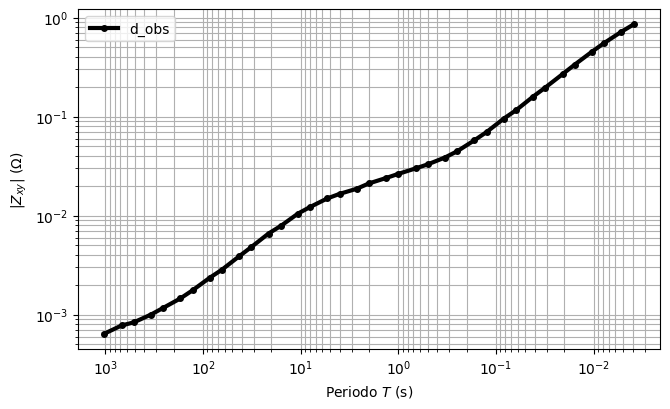

In [ ]:
#@title 3.3) Plot $|Z_{xy}|(T)$
plt.figure(figsize=(6.8, 4.2))
plt.loglog(periods, np.abs(Zxy), "k.-", lw=3, ms=8, label='d_obs')
plt.gca().invert_xaxis()
plt.xlabel(r"Periodo $T$ (s)")
plt.ylabel(r"$|Z_{xy}|$ (Ω)")
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()

### Profundidad de penetración

Se intenta usar la función $\texttt{mt.plot\_depth\_of\_penetration()}$ para obtener una referencia visual del rango de investigación asociado al dato.  
Si la función requiere atributos no disponibles en el tensor, el error correspondiente permitirá identificar esa limitación.

In [ ]:
#@title 3.4) Patch de fuentes para MTpy
import matplotlib.font_manager as fm

FP = fm.FontProperties

if not getattr(FP, "_mtpy_init_patch", False):
    FP._mtpy_base_init = FP.__init__

    def _mtpy_fp_init(self, *args, **kwargs):
        alias_map = {
            "fontsize": "size",
            "fontweight": "weight",
            "fontstyle": "style",
            "fontfamily": "family",
        }
        for old, new in alias_map.items():
            if old in kwargs and new not in kwargs:
                kwargs[new] = kwargs.pop(old)
            else:
                kwargs.pop(old, None)

        return FP._mtpy_base_init(self, *args, **kwargs)

    FP.__init__ = _mtpy_fp_init
    FP._mtpy_init_patch = True

if not getattr(FP, "_mtpy_from_any_patch", False):
    _orig_from_any = FP._from_any

    @classmethod
    def _mtpy_from_any(cls, arg):
        if arg is None:
            return cls()
        if isinstance(arg, cls):
            return arg

        if hasattr(arg, "get_family") and hasattr(arg, "get_style") and hasattr(arg, "get_weight") and hasattr(arg, "get_size"):
            try:
                return cls(
                    family=arg.get_family(),
                    style=arg.get_style(),
                    variant=getattr(arg, "get_variant", lambda: None)(),
                    weight=arg.get_weight(),
                    stretch=getattr(arg, "get_stretch", lambda: None)(),
                    size=arg.get_size(),
                )
            except Exception:
                return cls()

        if isinstance(arg, dict):
            return cls(**arg)

        return _orig_from_any(arg)

    FP._from_any = _mtpy_from_any
    FP._mtpy_from_any_patch = True

print("Matplotlib FontProperties patched for MTpy penetration depth.")

Matplotlib FontProperties patched for MTpy penetration depth.


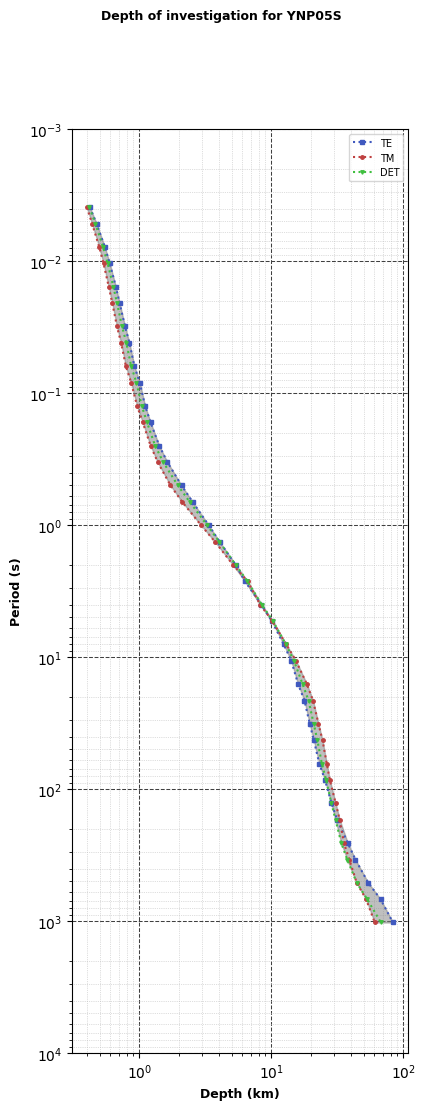

In [ ]:
#@title 3.5) Depth of Penetration con MTpy
plt.figure(1, figsize=(15, 12))
plot_doi = mt.plot_depth_of_penetration(fig_num=1)
plt.show()

## Bloque 4. Operador directo MT $1$D diferenciable

El forward calcula $Z(\omega)$ para un modelo $1$D estratificado usando un esquema recursivo desde el semiespacio hacia la superficie.  
Se implementa en TensorFlow para que el cálculo sea diferenciable y pueda integrarse directamente en el entrenamiento de la red.

In [ ]:
#@title 4.1) Forward MT $1$D (TensorFlow)
@tf.function
def MTforwardModelTF2(thicknesses_real, resistivities_real):
    frequencies = tf.cast(frequencies_np, dtype=tf.complex128)
    thicknesses = tf.cast(thicknesses_real, dtype=tf.complex128)
    resistivities = tf.cast(resistivities_real, dtype=tf.complex128)
    n = resistivities.shape[0]

    Z_out = tf.TensorArray(dtype=tf.complex128, size=0, dynamic_size=True)

    for frequency in frequencies:
        w = tf.cast(2.0 * math.pi, tf.complex128) * frequency
        impedances = tf.TensorArray(dtype=tf.complex128, size=n)

        impedances = impedances.write(n - 1, tf.sqrt(w * mu * 1j * resistivities[n - 1]))

        for j in range(n - 2, -1, -1):
            rho = resistivities[j]
            h = thicknesses[j]

            dj = tf.sqrt((w * mu * (1.0 / rho)) * 1j)
            wj = dj * rho
            ej = tf.exp(-2.0 * h * dj)

            Z_below = impedances.read(j + 1)
            rj = (wj - Z_below) / (wj + Z_below)
            re = rj * ej
            Zj = wj * ((1.0 - re) / (1.0 + re))
            impedances = impedances.write(j, Zj)

        Z_out = Z_out.write(Z_out.size(), impedances.read(0))

    return Z_out.stack()

print("Forward listo")

Forward listo


## Bloque 5. Parametrización del modelo de inversión y construcción del input

Aquí se define la malla de inversión sobre la cual se estimará el modelo de resistividad.  
Se fija el número de capas del modelo invertido y se construye un vector de espesores con crecimiento geométrico.  
Luego se prepara la entrada de la red a partir de la magnitud de la impedancia observada.

> En el código actual, la red usa como entrada únicamente $|Z_{xy}(\omega)|$.

### Malla de inversión

- Se define una malla con $n_{\text{layer}}$ resistividades.
- Los espesores siguen un crecimiento geométrico controlado por $z_{\text{factor}}$.

In [ ]:
#@title 5.1) Parámetros de malla de inversión  #@param {display-mode:"form"}
dz = 100.0  #@param {type:"number"}
n_layer = 25  #@param {type:"integer", min:4, max:120, step:1}
z_factor = 1.23  #@param {type:"number", min:1.02, max:2.0, step:0.01}

layer_thicknesses_inv = (dz * (z_factor ** np.arange(n_layer - 1))).astype(np.float64)
print("sum thickness (m):", float(layer_thicknesses_inv.sum()))

sum thickness (m): 62081.74367251096


### Construcción del input

La red recibe como entrada la magnitud observada $|Z_{xy}(\omega)|$, organizada como un vector.

In [ ]:
#@title 5.2) Construir input $x = |Z|$
x_in_np = np.abs(z_obs.numpy()).astype(np.float32)
x_in = tf.constant(x_in_np.reshape(1, -1), dtype=tf.float32)

print("Input dim =", x_in.shape[1], "| rango |Z|:", float(x_in_np.min()), "→", float(x_in_np.max()))

Input dim = 37 | rango |Z|: 0.0006422033184207976 → 0.8517325520515442


## Bloque 6. Definición del modelo neuronal y restricciones físicas

En esta sección se define la arquitectura de la red neuronal encargada de predecir el modelo de resistividad.  
También se establece el rango físico permitido para las resistividades, de modo que la salida de la red, originalmente acotada por una función sigmoide, se transforme a valores físicamente razonables.

### Arquitectura de la red

- **neurons**: tamaño de la representación interna.
- **n_res_blocks**: número de bloques residuales.
- **use_residual**: activa conexiones residuales.
- **l1_strength**: regularización L1 sobre los pesos.

In [ ]:
#@title 6.1) Hiperparámetros de la red  #@param {display-mode:"form"}
neurons = 256  #@param {type:"integer", min:16, max:1024, step:16}
n_res_blocks = 5  #@param {type:"integer", min:0, max:20, step:1}
activation = "relu"  #@param ["relu","elu","tanh","swish"]
use_residual = True  #@param {type:"boolean"}
l1_strength = 1e-6  #@param {type:"number"}

In [ ]:
#@title 6.2) Construir la red
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.regularizers import l1

tf.keras.backend.clear_session()
tf.random.set_seed(0)

input_dim = int(x_in.shape[1])
output_dim = int(n_layer)

def build_model(input_dim, output_dim, neurons, n_res_blocks, activation, use_residual, l1_strength):
    inp = Input(shape=(input_dim,))
    x = Dense(neurons, activation=activation)(inp)
    for _ in range(n_res_blocks):
        h = Dense(neurons, activation=activation, kernel_regularizer=l1(l1_strength))(x)
        x = keras.layers.add([x, h]) if use_residual else h
    out = Dense(output_dim, activation="sigmoid")(x)
    return keras.Model(inp, out)

MTaeNET = build_model(input_dim, output_dim, neurons, n_res_blocks, activation, use_residual, l1_strength)
MTaeNET.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 37)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │      9,728 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     65,792 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ dense[0][0],      │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │     65,792 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 256)       │          0 │ add[0][0],        │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │     65,792 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 256)       │          0 │ add_1[0][0],      │
│                     │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │     65,792 │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 256)       │          0 │ add_2[0][0],      │
│                     │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 256)       │     65,792 │ add_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 256)       │          0 │ add_3[0][0],      │
│                     │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 25)        │      6,425 │ add_4[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 345,113 (1.32 MB)

 Trainable params: 345,113 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

### Rango físico de resistividad

Se restringe $\rho$ al intervalo $[\rho_{\min}, \rho_{\max}]$ para mantener la solución dentro de un rango interpretable y evitar valores extremos durante la inversión.

In [ ]:
#@title 6.3) Rango permitido de resistividad  #@param {display-mode:"form"}
rho_min = 1.0     #@param {type:"number"}
rho_max = 1000.0  #@param {type:"number"}
print("rho in [", rho_min, ",", rho_max, "] Ω m")

rho in [ 1.0 , 1000.0 ] Ω m


## Bloque 7. Definición de la función de costo guiada por física

La función objetivo combina un término de ajuste a datos y un término de regularización por suavidad.  
El primero obliga a que la respuesta calculada mediante el forward MT se acerque a la impedancia observada, mientras que el segundo controla variaciones abruptas del modelo invertido.

### Regularización

- La pérdida de datos usa $\log(Z)$ complejo.
- La regularización penaliza cambios bruscos en $\log(\rho)$.
- El peso relativo de la regularización está controlado por $\lambda = \texttt{smooth\_weight}$.

In [ ]:
#@title 7.1) Regularización  #@param {display-mode:"form"}
smooth_weight = 0.1  #@param {type:"number"}
print("smooth_weight =", smooth_weight)

smooth_weight = 0.1


### Función de costo

$$
\min_{\boldsymbol{\theta}}\;\mathcal{L}(\boldsymbol{\theta})
=
\mathcal{L}_d(\boldsymbol{\theta})+\lambda\,\mathcal{L}_s(\boldsymbol{\theta})
$$

$$
\mathcal{L}_d(\boldsymbol{\theta})
=
\dfrac{1}{2}\,
\left\|
\log\!\left(Z_{\mathrm{obs}}\right)
-
\log\!\left(Z_{\mathrm{pred}}(\boldsymbol{\theta})\right)
\right\|_2^2
$$

$$
\mathcal{L}_s(\boldsymbol{\theta})
=
\left\|
\dfrac{
\log\!\left(\rho_{i+1}(\boldsymbol{\theta})\right)
-
\log\!\left(\rho_i(\boldsymbol{\theta})\right)
}{
\log(h_i)
}
\right\|_2^2
$$

In [ ]:
#@title 7.2) Definir loss_data + loss_smooth
def loss_smooth(res_pred, thicknesses_inv):
    logrho = tf.reshape(tf.math.log(res_pred + 1e-30), (-1,))
    diff = logrho[1:] - logrho[:-1]
    denom = tf.math.log(tf.constant(thicknesses_inv, dtype=tf.float32) + 1e-12)
    r = diff / (denom + 1e-12)
    return tf.reduce_sum(tf.square(r))

def loss_data_complex_log(z_obs_c, z_pred_c):
    eps = tf.complex(tf.constant(1e-30, tf.float64), tf.constant(0.0, tf.float64))
    r = tf.math.log(z_obs_c + eps) - tf.math.log(z_pred_c + eps)
    return 0.5 * tf.reduce_sum(tf.square(tf.abs(r)))

print("Loss definida")

Loss definida


## Bloque 8. Entrenamiento del modelo

En esta etapa se optimizan los pesos de la red neuronal para minimizar la función de costo total,

$$
\mathcal{L}=\mathcal{L}_d + \lambda\,\mathcal{L}_s
$$

con $\lambda = \texttt{smooth\_weight}$.

En cada iteración, la red predice un modelo de resistividad, este modelo se transforma en una respuesta MT mediante el operador directo y se actualizan los pesos usando gradientes.

In [ ]:
#@title 8.1) Parámetros de entrenamiento  #@param {display-mode:"form"}
epochs = 200  #@param {type:"integer", min:10, max:5000, step:10}
learning_rate = 1e-3  #@param {type:"number"}
optimizer_name = "AdamW"  #@param ["Adam","AdamW","RMSprop","SGD"]
weight_decay = 1e-4  #@param {type:"number"}
clipnorm = 1.0  #@param {type:"number"}

In [ ]:
#@title 8.2) Ejecutar entrenamiento (imprime cada 50 iteraciones)
opt = make_optimizer(optimizer_name, learning_rate, wd=weight_decay, clipnorm=clipnorm)

@tf.function
def train_step():
    with tf.GradientTape() as tape:
        sig = tf.reshape(MTaeNET(x_in, training=True), (-1,))

        a = tf.constant(np.log10(rho_min), tf.float32)
        b = tf.constant(np.log10(rho_max), tf.float32)
        log10rho = a + sig*(b-a)
        res_pred = tf.pow(tf.constant(10.0, tf.float32), log10rho)

        z_pred = MTforwardModelTF2(layer_thicknesses_inv, tf.cast(res_pred, tf.float64))
        z_obs_c = tf.cast(z_obs, tf.complex128)

        Ld = loss_data_complex_log(z_obs_c, z_pred)
        Ls = loss_smooth(res_pred, layer_thicknesses_inv)
        L = Ld + tf.cast(smooth_weight * Ls, tf.float64)

    grads = tape.gradient(L, MTaeNET.trainable_weights)
    opt.apply_gradients(zip(grads, MTaeNET.trainable_weights))
    return L, Ld, Ls

PRINT_EVERY = 50  #@param {type:"integer", min:1, max:100, step:1}

loss_hist, Ld_hist, Ls_hist = [], [], []
for it in range(int(epochs)):
    L, Ld, Ls = train_step()

    Lf  = float(L.numpy())
    Ldf = float(Ld.numpy())
    Lsf = float(Ls.numpy())

    loss_hist.append(Lf)
    Ld_hist.append(Ldf)
    Ls_hist.append(Lsf)

    if (it % PRINT_EVERY == 0) or (it == int(epochs) - 1):
        print(f"Iter {it:5d}/{int(epochs)-1} | Loss={Lf:.6g} | Data={Ldf:.6g} | Smooth={Lsf:.6g}")

print("Final | Loss:", loss_hist[-1], "| Data:", Ld_hist[-1], "| Smooth:", Ls_hist[-1])

Iter     0/199 | Loss=23.9888 | Data=23.7532 | Smooth=2.35563
Iter    50/199 | Loss=0.030148 | Data=0.0139951 | Smooth=0.161529
Iter   100/199 | Loss=0.0296499 | Data=0.0134677 | Smooth=0.161822
Iter   150/199 | Loss=0.0311209 | Data=0.0147506 | Smooth=0.163703
Iter   199/199 | Loss=0.029658 | Data=0.0134972 | Smooth=0.161608
Final | Loss: 0.02965797643997955 | Data: 0.013497192150738711 | Smooth: 0.16160783171653748


## Bloque 9. Evaluación y análisis de resultados

Finalmente, se analiza el desempeño de la inversión desde cuatro perspectivas complementarias:

1. la evolución de la función de costo durante el entrenamiento,  
2. el ajuste entre la respuesta observada y la respuesta predicha,  
3. la forma del modelo de resistividad invertido,  
4. y métricas cuantitativas calculadas sobre $\log |Z|$.

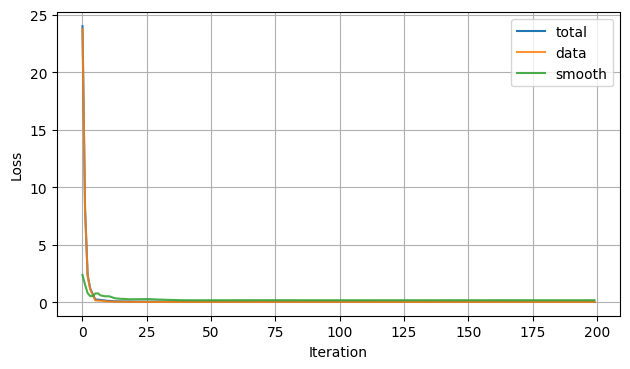

In [ ]:
#@title 9.1) Plot pérdidas
plt.figure(figsize=(6.4, 3.8))
plt.plot(loss_hist, label="total")
plt.plot(Ld_hist, label="data", alpha=0.85)
plt.plot(Ls_hist, label="smooth", alpha=0.85)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Ajuste observado vs predicho

Se compara la magnitud observada de la impedancia con la respuesta producida por el modelo invertido.

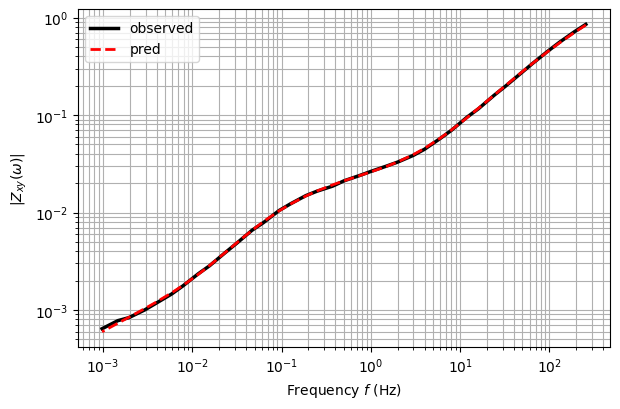

In [ ]:
#@title 9.2) Plot $|Z_{xy}|$ observado vs predicho
sig_np = MTaeNET(x_in, training=False).numpy().reshape(-1)
res_pred_np = sigmoid_to_rho(sig_np, rho_min, rho_max)
z_pred_np = MTforwardModelTF2(layer_thicknesses_inv, res_pred_np).numpy()

plt.figure(figsize=(6.3, 4.2))
plt.loglog(frequencies_np, np.abs(z_obs.numpy()), "k", lw=2.5, label="observed")
plt.loglog(frequencies_np, np.abs(z_pred_np), "--r", lw=2.0, label="pred")
plt.xlabel(r"Frequency $f$ (Hz)")
plt.ylabel(r"$|Z_{xy}(\omega)|$")
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()

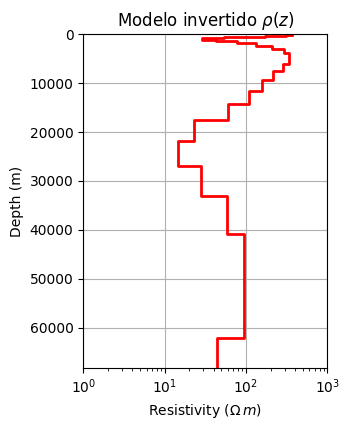

In [ ]:
#@title 9.3) Plot modelo invertido $\rho(z)$
fig, ax = plt.subplots(figsize=(3.6, 4.4))
drawModel1D(ax, layer_thicknesses_inv, res_pred_np, plot="semilogx",
            color="red", linewidth=2.0)
plt.xlim([rho_min, rho_max])
plt.ylim([layer_thicknesses_inv.sum()*1.1, 0])
plt.title(r"Modelo invertido $\rho(z)$")
plt.tight_layout()
plt.show()

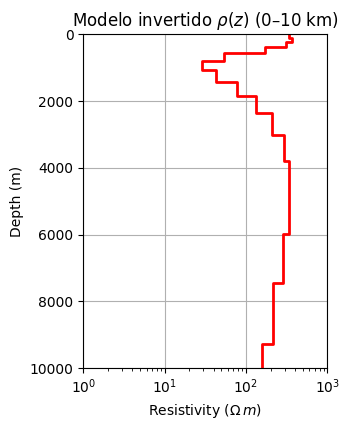

In [ ]:
#@title 9.4) Plot modelo invertido $\rho(z)$ (zoom primeros 10 km)  #@param {display-mode:"form"}
ZOOM_FIRST_KM = 10.0  #@param {type:"number"}  # km

fig, ax = plt.subplots(figsize=(3.6, 4.4))
drawModel1D(ax, layer_thicknesses_inv, res_pred_np, plot="semilogx",
            color="red", linewidth=2.0)

plt.xlim([rho_min, rho_max])
zmax_m = ZOOM_FIRST_KM * 1000.0
plt.ylim([zmax_m, 0])

plt.title(rf"Modelo invertido $\rho(z)$ (0–{ZOOM_FIRST_KM:g} km)")
plt.tight_layout()
plt.show()

### Métricas sobre $\log |Z_{xy}(\omega)|$

Se calculan tres métricas sobre la diferencia entre la magnitud observada y la predicha en escala logarítmica:

- RMSE$(\log |Z|)$,
- MAE$(\log |Z|)$,
- $R^2(\log |Z|)$.

In [ ]:
#@title 9.5) Métricas sobre $\log|Z|$
import pandas as pd

Zobs = z_obs.numpy()
Zprd = z_pred_np

Aobs = np.abs(Zobs)
Aprd = np.abs(Zprd)

logAobs = np.log(np.maximum(Aobs, np.finfo(float).tiny))
logAprd = np.log(np.maximum(Aprd, np.finfo(float).tiny))

rmse_logabs = np.sqrt(np.mean((logAprd - logAobs)**2))
mae_logabs  = np.mean(np.abs(logAprd - logAobs))

ss_res = np.sum((logAprd - logAobs)**2)
ss_tot = np.sum((logAobs - np.mean(logAobs))**2)
r2_logabs = 1.0 - ss_res / np.maximum(ss_tot, np.finfo(float).tiny)

df = pd.DataFrame({
    "Métrica": [r"RMSE(log|Z|)", r"MAE(log|Z|)", r"$R^2(log|Z|)"],
    "Valor":  [rmse_logabs, mae_logabs, r2_logabs]
})

df_show = df.copy()
df_show["Valor"] = df_show["Valor"].map(lambda x: f"{x:.6g}")

display(
    df_show.style
    .set_properties(**{"text-align":"left"})
    .set_table_styles([{"selector":"th","props":[("text-align","left")]}])
    .hide(axis="index")
)

Métrica,Valor
RMSE(log|Z|),0.0206359
MAE(log|Z|),0.0144488
$R^2(log|Z|),0.999901
